<a href="https://colab.research.google.com/github/meka-williams/BBW-Insight-Dashboard/blob/main/Problem%20Set%2006/Problem_set_06_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook is part the of Dr. Christoforos Christoforou's course materials. You may not, nor may you knowingly allow others to reproduce or distribute lecture notes, course materials or any of their derivatives without the instructor's express written consent.


## Problem Set 06 : Workshop on using PCA
This problem set is intended as a workshop to practice the use of Singular Value Decomposition and Principal Component Analysis as two ways to perform Matrix Factorization and Dimensionality Reduction.



In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()


## Challenge 1: Apply PCA on sample data - using numpy.
In this section you need to apply PCA on a simulated dataset. You need to extract the prinipal components and use them to reduce the dimensionality of the data. For this challenge **do not use** sklearn library. Some starting code is provided for you in each cell. Complete all the exercises to earn all points in this challenge.

In [2]:
#
# Generate the dataset, split it into
#
rng = np.random.RandomState(4)     # Seed the random number generator.
n_samples = 1000                    # Specify the number of samples.
X_all = np.array([5,1,1,1,2]).T + np.dot(rng.rand(5, 5), rng.randn(5, n_samples)).T
X_train, X_test = X_all[:n_samples//2,:],X_all[n_samples//2:,:]


### Answer the following question.
Use the cell below to find the answer to the following questions.

- What is the dimensions of `X_train` and `X_test`?
- How many `features` does each sample has (i.e. what is the dimensionality of the observations in data matrix X_all)?
- Create three 2D scatter plots to show the relationship between to features-pairs (1,2), (1,4), (3,4)? Make sure you label each scatter plot.

As an example, the following code create a scatter plot between the 1st and 3rd feature dimension
```python
plt.scatter(X_train[:,1],X_train[:,3])
plt.title("Scatter plot between feature 2 and feature 4")
plt.xlabel("Feature 2")
plt.ylabel("Feature 4")
plt.axis("square")

```

In [6]:
#
# Use this cell to figure out the anwers to the questions above.
#

print(f"Dimensions of X_train: {X_train.shape}")
print(f"Dimensions of X_test: {X_test.shape}")
print(f"Number of features: {X_all.shape[1]}")

Dimensions of X_train: (500, 5)
Dimensions of X_test: (500, 5)
Number of features: 5


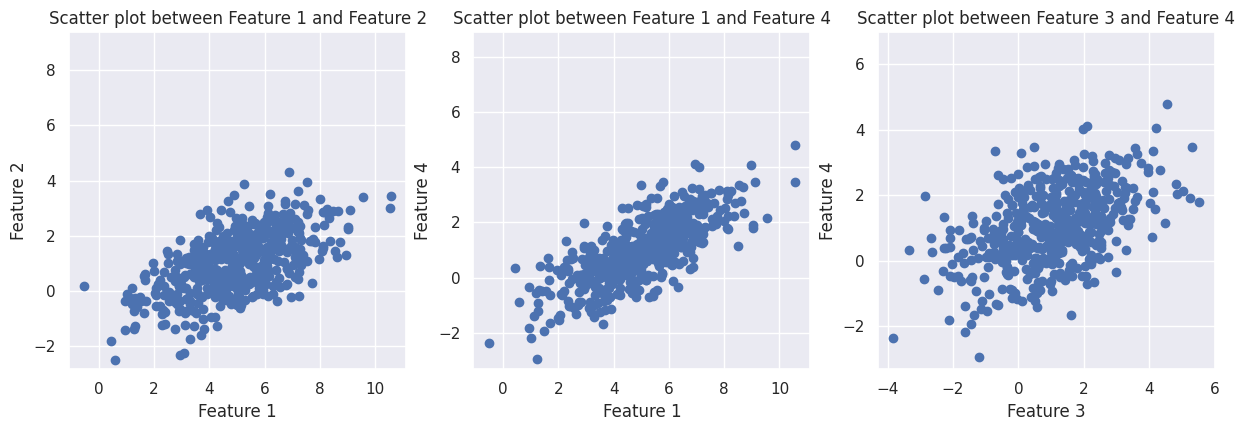

In [4]:
#
# Display the scatter plot between the feature pairs (1,2), (1,4), (3,4)
#
plt.figure(figsize=(20,10))

# Plot the scatter plot between feature-pair (1,2)
plt.subplot(1,4,1)
plt.scatter(X_train[:,0],X_train[:,1])
plt.title("Scatter plot between Feature 1 and Feature 2")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.axis("square")


# Plot the scatter plot between feature-pair (1,4)
plt.subplot(1,4,2)
plt.scatter(X_train[:,0],X_train[:,3])
plt.title("Scatter plot between Feature 1 and Feature 4")
plt.xlabel("Feature 1")
plt.ylabel("Feature 4")
plt.axis("square")

# Plot the scatter plot between feature-pair (3,4)
plt.subplot(1,4,3)
plt.scatter(X_train[:,2],X_train[:,3])
plt.title("Scatter plot between Feature 3 and Feature 4")
plt.xlabel("Feature 3")
plt.ylabel("Feature 4")
plt.axis("square")


plt.show()

### Exercise 1.1 : Calculate the covariance matrix.
Calculate the covariance matrix of the training data matrix `X_train`. Show all you steps as outlined in the skeleton code provided. In particular, you need to
calculate the observations' mean; subtract the mean from the data matrix; standardize the observations by dividing each feature with its corresponding standard deviation; and calculate the covarnace matrix.

**Hints**
  - Notice that you can find the mean of an array `A` along a particular dimension `b`, using the numpy command `np.mean(A,axis=b)`. In case `b=0` the mean is taken along the 0th dimension (i.e along the rows), when `b=1` the mean is taken along the 1st dimension (i.e. along the columns). Similarly, you can find the standard deviation of the array using the command `np.std(A,axis=b)`

  - Python `broadcasting` allows you to perform artithmetic operation on arrays with different sizes, thus vectorizing the arithmetic operations and eliminates the need for using inefficent for loops. The following example shows how boradcasting is used to add  a row vector from every row in the 2D array.
  ```python
    # Example of using broadcasting
    sample = np.array([[2,4], [10,-5]])
    to_add = np.array([3,7])
    sample_add_using_broadcasting  = sample + to_add
    print(sample)
    print(sample_add_using_broadcasting)
  ```
  - The covariance matrix of a data matrix $X\in \mathbb{R}^{N\times D}$(i.e. a matrix with $N$ rows/observations and $D$ columns/features is defined as
    $\frac{1}{N-1} X^T X$ where the term $\frac{1}{N-1}$ is the normalization constant, and $^T$ denotes the matrix transpose.
     In numpy, we can multiply two numpy arrays/matrices using the `np.matmul()` method and we can transpose a matrix by accessing the `.T`  property of the array (i.e. `np.matmul(X.T,X)`).


In [7]:
#
# Calcualte the mean of X_train
#

X_mean = np.mean(X_train, axis=0)

#
# Subtract the mean from
#

X_train_mean_subtracted = X_train - X_mean

#
# Standarized observation to unit variance (i.e. divide by standard deviation)
#

X_std = np.std(X_train_mean_subtracted, axis=0)
X_train_std = X_train_mean_subtracted / X_std


#
# Calculate the covariance of the standarized observations.
# Make sure you use the appropripate normalization constant

X_train_cov = np.matmul(X_train_std.T, X_train_std) / (X_train_std.shape[0] - 1)


#### Answer the following questions:
Use the cell below to answer the following questions and show your work.

- Print the content of the covariance matrix.
- What are the dimensions of the covariance matrix `X_train_cov`
- What values do you see on the diagonal elements of the covariance matrix.
- Which feature-pairs have the largest covariance value; what is that value.

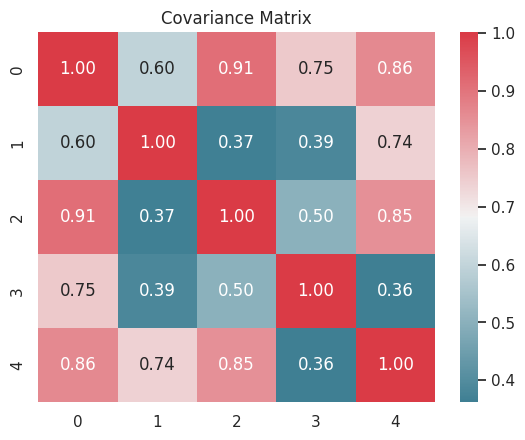


Content of the covariance matrix: [[1.00200401 0.59615502 0.91194702 0.75460585 0.8632635 ]
 [0.59615502 1.00200401 0.36660994 0.38650954 0.73888442]
 [0.91194702 0.36660994 1.00200401 0.50077827 0.85131988]
 [0.75460585 0.38650954 0.50077827 1.00200401 0.36278094]
 [0.8632635  0.73888442 0.85131988 0.36278094 1.00200401]]

Dimensions of the covariance matrix X_train_cov: (5, 5)

Values on the diagonal elements of the covariance matrix: [1.00200401 1.00200401 1.00200401 1.00200401 1.00200401]

Largest off-diagonal covariance value: 0.9119
Feature-pairs with the largest off-diagonal covariance value:
  Feature 1 and Feature 3
  Feature 3 and Feature 1


In [27]:
#
# Complete the code below to display a heatmap of the Covariance matrix
#
colormap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(X_train_cov, cmap= colormap, annot=True, fmt=".2f")
plt.title("Covariance Matrix")
plt.show()


#
# Write code to find the answers to the questions in the cell above.
#

print(f"\nContent of the covariance matrix: {X_train_cov}")

print(f"\nDimensions of the covariance matrix X_train_cov: {X_train_cov.shape}")

print(f"\nValues on the diagonal elements of the covariance matrix: {np.diag(X_train_cov)}")

# Find which feature-pairs have the largest covariance value
# Create a copy to avoid modifying the original matrix for display
abs_X_train_cov = np.abs(X_train_cov.copy())

# Set diagonal elements to 0 to find largest OFF-diagonal value
np.fill_diagonal(abs_X_train_cov, 0)

max_cov = np.max(abs_X_train_cov)
# Get the indices of the maximum value
max_cov_indices = np.argwhere(abs_X_train_cov == max_cov)

print(f"\nLargest off-diagonal covariance value: {max_cov:.4f}")
print("Feature-pairs with the largest off-diagonal covariance value:")
for pair in max_cov_indices:
    print(f"  Feature {pair[0]+1} and Feature {pair[1]+1}")

### Exercise 1.2: Estimate the Eigen-vectors and Eigen-values of the covariance matrix.
The principal components of a covariance matrix are the eigen-vectors of the covariance matrix. The variance of each principal component is proportional to the eigen-value of its corresponding eigen-vector.

As part of this exercise you need to extract the two the principal component of the covariance matrix that have the highest variance. Then answer the following questions.

**Hints**
- The numpy method `eigh` can be used to estimate the eighen-vectors and eigen-values of a square symetric matrix. For example,
```python
  a_symetric_square_matrix = np.array([[1,0.7],[0.7, 1]])
  eig_vals, eig_vecs  = np.linalg.eigh(a_symetric_square_matrix)
```




In [11]:
#
# Calculate the eigenvectors and eigenvalues of the covariance matrix.
#

eig_vals, eig_vecs = np.linalg.eigh(X_train_cov)



#### Answer the following questions.
Use the code-cell below to find the answer to the following questions and show your work.
- Print the eigen-vector with the largest eigen-value, also print the eigen-value itself, and the index of the vector in the `eig_vecs` matrix

- Print the eigen-vector with the second largest eigen-value, also print the eigen-value itself, and the index of the vector in the `eig_vecs` matrix

- Calculate the percentage of the variance in the data that is captured by the three eigen-vectors with the largest eigen-values.

- Calculate the total variance captured by the two eigen-vectors with the smallest eigen-values.

- What is the minimum number of principal component you can use to ensure that the least `85%` of the variance is captured in the reduced dataset.  

In [18]:
#
# Use this cell to find the answers to the above questions, and to show your work.
#

# Sort eigenvalues in descending order
sorted_indices = np.argsort(eig_vals)[::-1]
sorted_eig_vals = eig_vals[sorted_indices]
sorted_eig_vecs = eig_vecs[:, sorted_indices]

# Print the eigen-vector with the largest eigen-value
print(f"Eigen-vector with the largest eigen-value: {sorted_eig_vecs[:, 0]}")
print(f"Largest eigen-value: {sorted_eig_vals[0]:.4f}")
print(f"Index of the largest eigen-value (in original array): {sorted_indices[0]}")

# Print the eigen-vector with the second largest eigen-value
print(f"\nEigen-vector with the second largest eigen-value: {sorted_eig_vecs[:, 1]}")
print(f"Second largest eigen-value: {sorted_eig_vals[1]:.4f}")
print(f"Index of the second largest eigen-value (in original array): {sorted_indices[1]}")

# Calculate the percentage of the variance captured by the three eigen-vectors with the largest eigen-values
total_variance = np.sum(eig_vals)
variance_top_3 = np.sum(sorted_eig_vals[:3])
percentage_variance_top_3 = (variance_top_3 / total_variance) * 100
print(f"\nPercentage of variance captured by the three largest eigen-vectors: {percentage_variance_top_3:.2f}%")

# Calculate the total variance captured by the two eigen-vectors with the smallest eigen-values
variance_smallest_2 = np.sum(sorted_eig_vals[-2:])
print(f"\nTotal variance captured by the two smallest eigen-vectors: {variance_smallest_2:.4f}")

# Minimum number of principal components to ensure at least 85% of variance
explained_variance_ratio = eig_vals / total_variance
sorted_explained_variance_ratio = explained_variance_ratio[sorted_indices]

cumulative_variance = np.cumsum(sorted_explained_variance_ratio)

num_components_85_percent = np.where(cumulative_variance >= 0.85)[0][0] + 1
print(f"\nMinimum number of principal components to capture at least 85% of the variance: {num_components_85_percent}")

Eigen-vector with the largest eigen-value: [-0.51942035 -0.37843605 -0.46646783 -0.36578764 -0.48538214]
Largest eigen-value: 3.5934
Index of the largest eigen-value (in original array): 4

Eigen-vector with the second largest eigen-value: [-0.18273974  0.57367564 -0.1267296  -0.68653272  0.38744661]
Second largest eigen-value: 0.7676
Index of the second largest eigen-value (in original array): 3

Percentage of variance captured by the three largest eigen-vectors: 99.59%

Total variance captured by the two smallest eigen-vectors: 0.0205

Minimum number of principal components to capture at least 85% of the variance: 2


### Exercise 1.3 Dimensionality Reduction using Principal Components
Use the principal component you calculated in the previous step to reduce the dimensionality of the feature space.

- First, you must identify the two principal component with the highest variance (i.e. using the eigen-values you calculated in the previous code-cells).Then append the two principal components into their own matrix `PCA_mx` such that the metrix columns correspond to the selected Principal Components.

- Use the resulting matrix `PCA_mx` to reduce the dimensions in the training set; from its original dimension down to two dimentions. You can do that by multiplying the *standaraized* training set X_train_std with the principal component's matrix `PCA_mx`. Store the resulting reduced-dimensionality training set into a variable `X_train_proj`

- Use the resulting matrix `PCA_mx` to reduce the dimensions in the testing set; `X_test`. (*Hint: you must first standardize the testing set; using only quantities you calculated from the training set. Remember, standardization is the process of transforming the data to zero mean, and unit standard deviation*). Store the resulting reduced-dimensionality training set into a variable `X_test_proj`    




In [14]:
#
# Create a matrix whose columns are the two major principal component.
#

PCA_mx = sorted_eig_vecs[:, :2]

#
# Project the training set X_train onto the two major principal Components.
# Use the matrix PCA_mx

X_train_proj = np.matmul(X_train_std, PCA_mx)


In [15]:
#
# Project the test dataset X_test onto the two major principal components
# See hint for answering.
#

X_test_mean_subtracted = X_test - X_mean

X_test_std = X_test_mean_subtracted / X_std

X_test_proj = np.matmul(X_test_std, PCA_mx)

#### Answer the following questions
Use the code-cells below to find the anwers to the following question, and display the requested figures.

- What is the shape of the matrix `X_train_proj` and what does each dimension represents.

- What is the shape of the matrix `X_test_proj` and what does each dimension represents.

- Display a scatter-plot showing the `X_train_proj` data.

- Display a scatter-plot showing the `X_test_proj` data.

- Calculate the covariance matrix of `X_train_proj` and identify what is the covariance between the first and second features.

- Calculate the covariance matrix of `X_test_proj` and identify what is the covariance between the first and second features.





In [28]:
#
# Use this code-cell to find the answer to the questions above.
#

print(f"Shape of X_train_proj: {X_train_proj.shape}")
print("Each dimension in X_train_proj represents a principal component. The shape (500, 2) means 500 samples projected onto 2 principal components.")

print(f"\nShape of X_test_proj: {X_test_proj.shape}")
print("Each dimension in X_test_proj represents a principal component. The shape (500, 2) means 500 samples projected onto 2 principal components.")

# Calculate covariance matrix of X_train_proj
cov_X_train_proj = np.cov(X_train_proj.T)
print(f"\nCovariance matrix of X_train_proj: {cov_X_train_proj}")
print(f"Covariance between the first and second features of X_train_proj: {cov_X_train_proj[0, 1]:.4f}")

# Calculate covariance matrix of X_test_proj
cov_X_test_proj = np.cov(X_test_proj.T)
print(f"\nCovariance matrix of X_test_proj: {cov_X_test_proj}")
print(f"Covariance between the first and second features of X_test_proj: {cov_X_test_proj[0, 1]:.4f}")

Shape of X_train_proj: (500, 2)
Each dimension in X_train_proj represents a principal component. The shape (500, 2) means 500 samples projected onto 2 principal components.

Shape of X_test_proj: (500, 2)
Each dimension in X_test_proj represents a principal component. The shape (500, 2) means 500 samples projected onto 2 principal components.

Covariance matrix of X_train_proj: [[3.59342865e+00 1.42393334e-17]
 [1.42393334e-17 7.67595016e-01]]
Covariance between the first and second features of X_train_proj: 0.0000

Covariance matrix of X_test_proj: [[3.52048614 0.0425955 ]
 [0.0425955  0.60083566]]
Covariance between the first and second features of X_test_proj: 0.0426


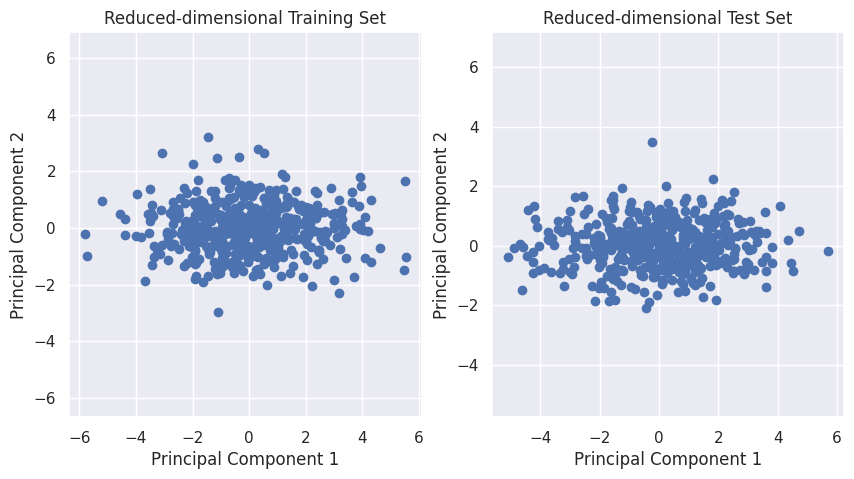

In [17]:
#
# Display the scatter-plots of the reduced-dimensional training and testing datasets.
#

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.scatter(X_train_proj[:, 0], X_train_proj[:, 1])
plt.title("Reduced-dimensional Training Set")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.axis('equal')


plt.subplot(1,2,2)
plt.scatter(X_test_proj[:, 0], X_test_proj[:, 1])
plt.title("Reduced-dimensional Test Set")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.axis('equal')
plt.show()

## Challenge 2: Apply PCA on sample data - Using the sklearn library

Principal Component Analysis is often used as a pre-processing and dimenionality-reductiion step in predictive modeling. As such, the sklearn library provides a helper class that encapulates the step of extracting the principal component.

Specifically, sklearn library provides the `PCA` class as part of its `sklearn.decomposition` module. You can clear a new instance of the PCA class as follows:
```python
  pca = PCA(n_components=2)
```
Notice the the variable `n_components` specifies the number of principal components we want to keep as part of the dimensionality reduction.

To apply the PCA class, we must make sure that we standardize the dataset, that is to transform the data so they have zero mean and unit variance. Sklearn provides another helper function the  performnce the standardization of the data. The `StandardScaler` class, part of the `sklearning.preprocessing` module achieves that. For example, the following code would standardize a matrix X
```python
D = np.array([[1,2],[4,9],[1,5],[7,19],[4,9]])
sc = StandardScaler()
sc.fit_transform(D)        # Learn the standardization parameters (i.e. mean, std parameters)
D_std = sc.transform(D)    # Standardize the dataset D

np.cov(D_std.T, ddof=False)# Check the covariance matrix.
```

Once the dataset is standardized, we can extract the principal components using the `fit` method of the `PCA` class, for example using

```python
pca.fit(D_std)
```
Notice that under the hood the fit method creates the covariance matrix, and solves the eigen-vector/eigen-value problem.

The principal components (i.e. eigen-vectors) and their explained variance (i.e. corresponding eigen-value) can be retrived from the fitted `pca` instance through the `explained_variance_` and `components_` attributes, such as
```python
print("Extracted Principal Components (i.e. eigen-vectors")
print(pca.components_)

print("Explained variabce of extracted components (i.e. eigen-values)
print(pca.explained_variance_)
```
Finally, project a dataset onto the extracted principal components, we can use the `transform` method of the PCA class. For example,
```python
D_projected = pca.transform(D_std)
```
**Exercise**
Using the reference code above, extract the principal components of the same sample dataset (as the one in Challenge 1), but now using the helper classes provided in the sklearn library.  Moreover, reduce the dimensionality of the `X_train` and `X_test` dataset by projecting to the two major principal components.




In [19]:
# Import the sklearn libaries
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [20]:
import numpy as np
#
# Create an Instance of the PCA class from sklearn.decomposition import PCA
#
pca = PCA(n_components=2)


#
# Standardize the training and testing dataset.
#

sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)


#
# Extract/learn the principal components
#
pca.fit(X_train_std)

#
# Project the train dataset onto the two major principal components.
#
X_train_proj_sklearn = pca.transform(X_train_std)


#
# Project the train dataset onto the two major principal components.
# Hint: do not forget to standardize the test dataset.

X_test_proj_sklearn = pca.transform(X_test_std)

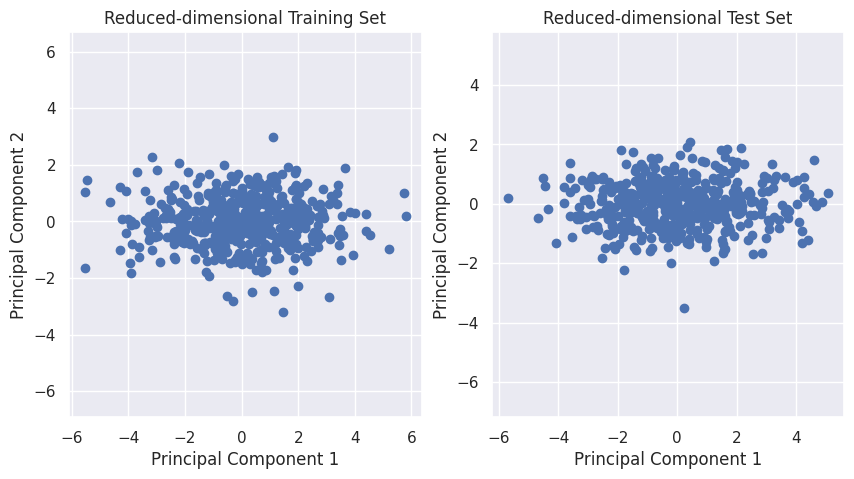

In [25]:
#
#  Display a scatter-plot showing the `X_train_proj_sklearn` data.
#
#  Display a scatter-plot showing the `X_test_proj_sklearn` data.
#. Hint: See sample code from Challenge 1.
#
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.scatter(X_train_proj_sklearn[:, 0], X_train_proj_sklearn[:, 1])
plt.title("Reduced-dimensional Training Set")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.axis('equal')


plt.subplot(1,2,2)
plt.scatter(X_test_proj_sklearn[:, 0], X_test_proj_sklearn[:, 1])
plt.title("Reduced-dimensional Test Set")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.axis('equal')
plt.show()

## Challenge 3: Perform PCA to reduce the dimensions of the wine dataset.

The code-cell below load an example dataset called `wine.data` as a panda's dataframe, and then split it into a training `X_train` and testing dataset `X_test`. Each observation corresponds to a particular wine brand and the features correspond to various characteristics associated with each wine (for example, 'Alcohol', 'Malic acid', 'Ash','Alcalinity of ash', 'Magnesium'). There are total 13 such features for each wine. Moreover, each wine belongs to one of three quality classes (i.e. 1,2 or 3). The class labels for each onservation are stored in the `y_train` and `y_test` vectors.


In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split

df_wine = pd.read_csv('https://archive.ics.uci.edu/ml/'
                      'machine-learning-databases/wine/wine.data',
                      header=None)

df_wine.columns = ['Class label', 'Alcohol', 'Malic acid', 'Ash',
                   'Alcalinity of ash', 'Magnesium', 'Total phenols',
                   'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',
                   'Color intensity', 'Hue',
                   'OD280/OD315 of diluted wines', 'Proline']

X, y = df_wine.iloc[:, 1:].values, df_wine.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                     stratify=y,
                     random_state=0)

### Exercise 3.1  

Your goal is to find a classifier to predict the quality class of a wine, given its observed features. You suspect that several of the features covay and that you are better off to reduce the number of dimession of the same before performing the classificaton.

In this exercise you are expected to use PCA to reduce the dimensionality of the original dataset from 13 down to two. Then use the K-NN to train a classifier that predicts the wine quality class.

Compare the performance of your classifier, to a classifier that uses all 13 features. You must report cross validation performance, and independent test performance.




--- K-NN Classifier with all 13 features ---
Cross-validation accuracy (full features): 0.9360 (+/- 0.0640)
Independent test set accuracy (full features): 0.9630

--- K-NN Classifier with 2 PCA features ---
Explained variance by PC1: 0.3695
Explained variance by PC2: 0.1843
Total explained variance by 2 PCs: 0.5539
Cross-validation accuracy (2 PCA features): 0.9600 (+/- 0.0716)
Independent test set accuracy (2 PCA features): 0.9259


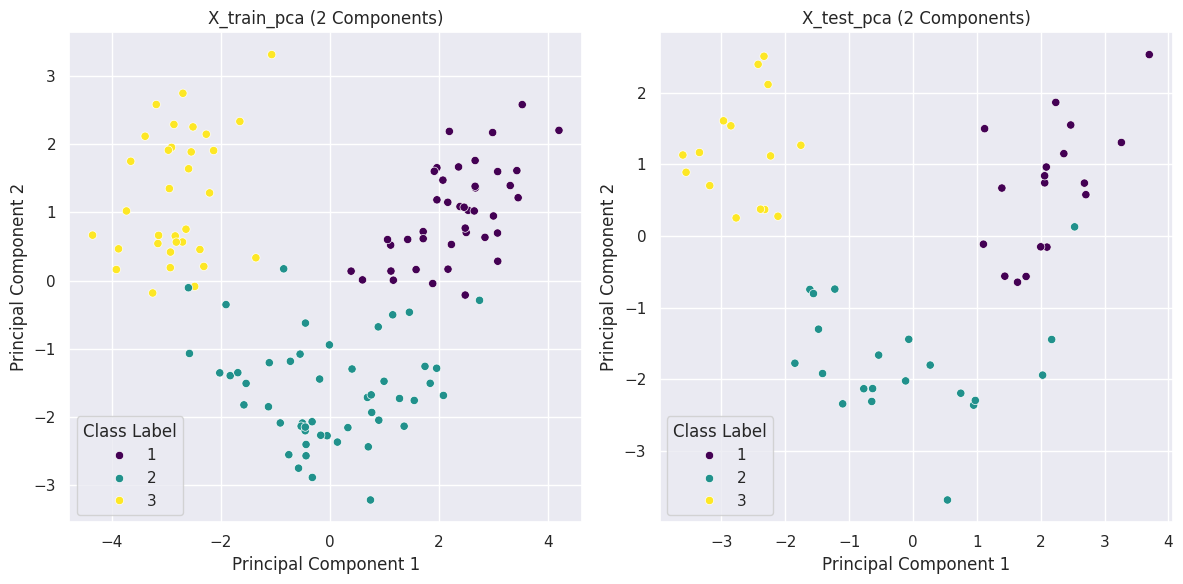

In [31]:
# Load and split the wine dataset
df_wine = pd.read_csv('https://archive.ics.uci.edu/ml/'
                      'machine-learning-databases/wine/wine.data',
                      header=None)

df_wine.columns = ['Class label', 'Alcohol', 'Malic acid', 'Ash',
                   'Alcalinity of ash', 'Magnesium', 'Total phenols',
                   'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',
                   'Color intensity', 'Hue',
                   'OD280/OD315 of diluted wines', 'Proline']

X, y = df_wine.iloc[:, 1:].values, df_wine.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                     stratify=y,
                     random_state=0)

# --- Step 1: Standardize the Wine Dataset ---
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

print("\n--- K-NN Classifier with all 13 features ---")
# --- Step 2: K-NN with all 13 features ---
knn_full = KNeighborsClassifier(n_neighbors=5) # Using 5 neighbors as a default

# Cross-validation performance
cv_scores_full = cross_val_score(knn_full, X_train_std, y_train, cv=5) # 5-fold cross-validation
print(f"Cross-validation accuracy (full features): {cv_scores_full.mean():.4f} (+/- {cv_scores_full.std() * 2:.4f})")

# Independent test set performance
knn_full.fit(X_train_std, y_train)
y_pred_full = knn_full.predict(X_test_std)
accuracy_full = accuracy_score(y_test, y_pred_full)
print(f"Independent test set accuracy (full features): {accuracy_full:.4f}")

print("\n--- K-NN Classifier with 2 PCA features ---")
# --- Step 3: PCA (2 components) + K-NN ---
# Apply PCA to reduce dimensions to 2
pca_wine = PCA(n_components=2)
X_train_pca = pca_wine.fit_transform(X_train_std)
X_test_pca = pca_wine.transform(X_test_std)

# Calculate explained variance ratio
explained_variance = pca_wine.explained_variance_ratio_
print(f"Explained variance by PC1: {explained_variance[0]:.4f}")
print(f"Explained variance by PC2: {explained_variance[1]:.4f}")
print(f"Total explained variance by 2 PCs: {sum(explained_variance):.4f}")

knn_pca = KNeighborsClassifier(n_neighbors=5)

# Cross-validation performance with PCA features
cv_scores_pca = cross_val_score(knn_pca, X_train_pca, y_train, cv=5)
print(f"Cross-validation accuracy (2 PCA features): {cv_scores_pca.mean():.4f} (+/- {cv_scores_pca.std() * 2:.4f})")

# Independent test set performance with PCA features
knn_pca.fit(X_train_pca, y_train)
y_pred_pca = knn_pca.predict(X_test_pca)
accuracy_pca = accuracy_score(y_test, y_pred_pca)
print(f"Independent test set accuracy (2 PCA features): {accuracy_pca:.4f}")

# Optional: Visualize the 2D PCA projected data
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train, palette='viridis')
plt.title('X_train_pca (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Class Label')

plt.subplot(1, 2, 2)
sns.scatterplot(x=X_test_pca[:, 0], y=X_test_pca[:, 1], hue=y_test, palette='viridis')
plt.title('X_test_pca (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Class Label')

plt.tight_layout()
plt.show()

#### Summarize the results of your analysis on the wine Dataset.
Use the following text-cell to summarize the results of your analysis. For example, consider the following questions: which classifer performces better and by how match? Did PCA dimensionallity reduction helped imporove the classification performance or not? Should you have used more or less principal components to improve classification performance. How much of the variance is captured by the reduced feature space?


#### Your results summary here

KNN Classifier with all 13 features

*   Cross validaton Accuracy: 0.94
*   Independent test set accuracy: 0.96

KNN Classifier with 2 PCA Features:
*   Variance by PC1: 0.34
*   Variance by PC2: 0.18
*   Variance by 2 PCs: 0.55
*   Cross-validation Accuracy: 0.96
*   Independent test set accuracy: 0.93


The KNN classifer using all 13 original features showed better performance on the independent test set (0.96) compared to the KNN classifer using 2 PCA features 2 PCA features (0.93). This is a differene of 3.7% between the accuracies. However, the KNN with 2 PCA features had a higher cross validation accuracy (0.96 vs. 0.94) indicating the classifer is more stable performance across training folds.

Reducing the dimesionality to just 2 principal components did not consistely improve classification performance. Although it showed a slight improvement in validaton accuracy, it led to a noticable decrease in accuracy on the independent test set.

The two principal components combined capture only 55.39% of the total variance in the dataset. This means a portion of the original data's information was lost during dimensionality reduction.

The two principal components selected for dimensionality reduction captured 55.39% of the total variance in the wine dataset.







Copyright Statement: Copyright © 2020 Christoforou. The materials provided by the instructor of this course, including this notebook, are for the use of the students enrolled in the course. Materials are presented in an educational context for personal use and study and should not be shared, distributed, disseminated or sold in print — or digitally — outside the course without permission. You may not, nor may you knowingly allow others to reproduce or distribute lecture notes, course materials as well as any of their derivatives without the instructor's express written consent.